<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 06</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Mezclas de distribuciones y estructura semántica</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>

## Pregunta directriz

> ¿Qué cambia en el problema generativo cuando el dataset ya no representa una sola distribución visual, sino una mezcla de distribuciones asociadas a categorías?

Hasta el notebook 05 trabajamos con una sola categoría de QuickDraw. Esa restricción fue deliberada: permitió estudiar datos, ruido, difusión directa, predicción de ruido y muestreo inverso sin introducir una variable semántica adicional. A partir de este punto la situación cambia. El dataset contiene varias clases y, por tanto, la distribución marginal de imágenes deja de tener una única estructura visual dominante.

Este notebook introduce esa transición. No entrenaremos todavía un modelo condicional; antes debemos precisar qué significa que un dataset etiquetado induzca una mezcla de distribuciones. Esta formulación será la base para entender por qué el siguiente notebook debe introducir $p_\theta(x\mid y)$ en lugar de limitarse a $p_\theta(x)$.

## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Formular un dataset etiquetado como una muestra de la distribución conjunta $p_{\mathrm{data}}(x,y)$.
2. Expresar la distribución marginal de imágenes como una mezcla de distribuciones condicionales.
3. Interpretar el prior empírico de clase $\widehat{\pi}_k$ y su relación con el muestreo no condicional.
4. Visualizar componentes semánticas mediante muestras, promedios, varianzas y proyecciones de baja dimensión.
5. Explicar por qué un modelo no condicional aprende una mezcla y no una categoría seleccionable.
6. Motivar formalmente la transición hacia modelos de difusión condicionales.

## Marco conceptual

En un dataset con una sola categoría, el problema generativo puede formularse de manera marginal: observamos imágenes $x$ y queremos aproximar $p_{\mathrm{data}}(x)$. Cuando aparece una etiqueta $y$, esa lectura sigue siendo válida, pero queda incompleta. La etiqueta no es solo un metadato conveniente; introduce una partición semántica del espacio de datos.

Para QuickDraw, una imagen de una casa y una imagen de un pez viven en el mismo espacio vectorial $\mathbb{R}^{784}$, pero no pertenecen a la misma componente semántica. Si ignoramos las etiquetas, el modelo debe asignar probabilidad a todas las regiones ocupadas por todas las clases. Si usamos las etiquetas, podemos estudiar la distribución de cada clase y luego decidir qué componente queremos muestrear.

Esta distinción es central para la IA generativa. Un modelo no condicional puede producir muestras plausibles de la mezcla total, pero no ofrece un mecanismo explícito para pedir una categoría concreta. Un modelo condicional introduce ese mecanismo al parametrizar una familia de distribuciones indexada por la condición.

## Formulación matemática

Consideremos un dataset etiquetado

$$
\mathcal{D}
=
\{(x_i,y_i)\}_{i=1}^{N},
\qquad
x_i\in\mathbb{R}^{d},
\qquad
y_i\in\{1,\dots,K\}.
$$

El prior empírico de la clase $k$ se estima como

$$
\widehat{\pi}_k
=
\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}\{y_i=k\}.
$$

La distribución empírica condicional asociada a esa clase puede escribirse como

$$
\widehat{p}_{k}(x)
=
\widehat{p}_{\mathrm{data}}(x\mid y=k)
=
\frac{1}{N_k}
\sum_{i:y_i=k}\delta(x-x_i),
$$

donde $N_k$ es el número de muestras de la clase $k$ y $\delta$ denota una masa puntual. La distribución marginal de imágenes es entonces la mezcla

$$
\widehat{p}_{\mathrm{data}}(x)
=
\sum_{k=1}^{K}
\widehat{\pi}_k\,
\widehat{p}_{k}(x).
$$

Si entrenamos un DDPM no condicional sobre este dataset, el objetivo de predicción de ruido queda promediado sobre la mezcla:

$$
\mathcal{L}(\theta)
=
\mathbb{E}_{y\sim\widehat{\pi},\,x_0\sim\widehat{p}(x\mid y),\,t,\epsilon}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_t,t)
\right\|_2^2
\right].
$$

La transición hacia modelos condicionales consiste en hacer explícita la variable semántica:

$$
\mathcal{L}_{\mathrm{cond}}(\theta)
=
\mathbb{E}_{y\sim\widehat{\pi},\,x_0\sim\widehat{p}(x\mid y),\,t,\epsilon}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_t,t,y)
\right\|_2^2
\right].
$$

La diferencia parece pequeña en notación, pero es estructural. En el primer caso el modelo aprende a cubrir la mezcla completa; en el segundo aprende a usar $y$ para seleccionar una componente de la mezcla.

<div style="margin: 18px 0 10px 0; text-align: center;">
  <img src="../assets/figures/formulacion_mezcla_distribuciones.png" alt="Formulación empírica de una mezcla etiquetada" style="max-width: 100%; border: 1px solid #d0d7de; border-radius: 6px;" />
</div>

<div style="text-align: center; color: #4a5568; font-size: 0.95em; margin-bottom: 6px;">
  La variable de clase permite pasar de una marginal no condicional a una familia de distribuciones condicionales seleccionables.
</div>

## Preparación del entorno

Usaremos un subconjunto multicategoría de QuickDraw con cinco clases y el mismo formato de imágenes de los notebooks anteriores. El cálculo se mantiene ligero: no hay entrenamiento, solo estimación empírica y visualización.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from difusion.data.quickdraw import load_quickdraw_npz

DATASET_PATH = ROOT / "data" / "quickdraw" / "processed" / "quickdraw_5class_10k_each_28x28.npz"

SEED = 20260424
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["image.cmap"] = "gray_r"

print("Dataset:", DATASET_PATH.relative_to(ROOT))

Dataset: data/quickdraw/processed/quickdraw_5class_10k_each_28x28.npz


## Criterio experimental

El propósito de este notebook no es mejorar la calidad de generación ni entrenar una red adicional. El experimento es estadístico y estructural: se toma un dataset etiquetado, se estima su composición empírica y se visualiza cómo las clases inducen componentes dentro del mismo espacio de datos.

Esta decisión mantiene separado el análisis de distribuciones del problema de arquitectura. Si mezcláramos aquí entrenamiento condicional, el estudiante podría atribuir al modelo propiedades que todavía pertenecen al dataset. Primero formalizamos la mezcla; después entrenaremos una red que use explícitamente la condición.

## Dataset etiquetado multicategoría

Cargamos el dataset como una muestra de la distribución conjunta. En esta etapa, la etiqueta $y$ no se usa para entrenar un modelo, sino para describir la estructura de la distribución empírica.

In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATASET_PATH}. "
        "Genere el dataset multicategoría antes de ejecutar este notebook."
    )

train = load_quickdraw_npz(DATASET_PATH, split="train")
val = load_quickdraw_npz(DATASET_PATH, split="val")

x_train = train.images
y_train = train.labels
class_names = np.array(train.class_names)
K = len(class_names)
d = int(np.prod(x_train.shape[1:]))

print("Clases:", class_names.tolist())
print("Train:", x_train.shape, x_train.dtype)
print("Val:", val.images.shape, val.images.dtype)
print("Dimensión vectorial d:", d)

Clases: ['house', 'cat', 'tree', 'fish', 'apple']
Train: (45000, 28, 28) uint8
Val: (5000, 28, 28) uint8
Dimensión vectorial d: 784


## Componentes empíricas de la mezcla

Las siguientes muestras no son una demostración estadística formal, pero sí hacen visible el punto conceptual: cada clase ocupa el mismo espacio de datos y, al mismo tiempo, tiene regularidades visuales propias. La mezcla marginal reúne esas regularidades sin conservar un mecanismo de selección.

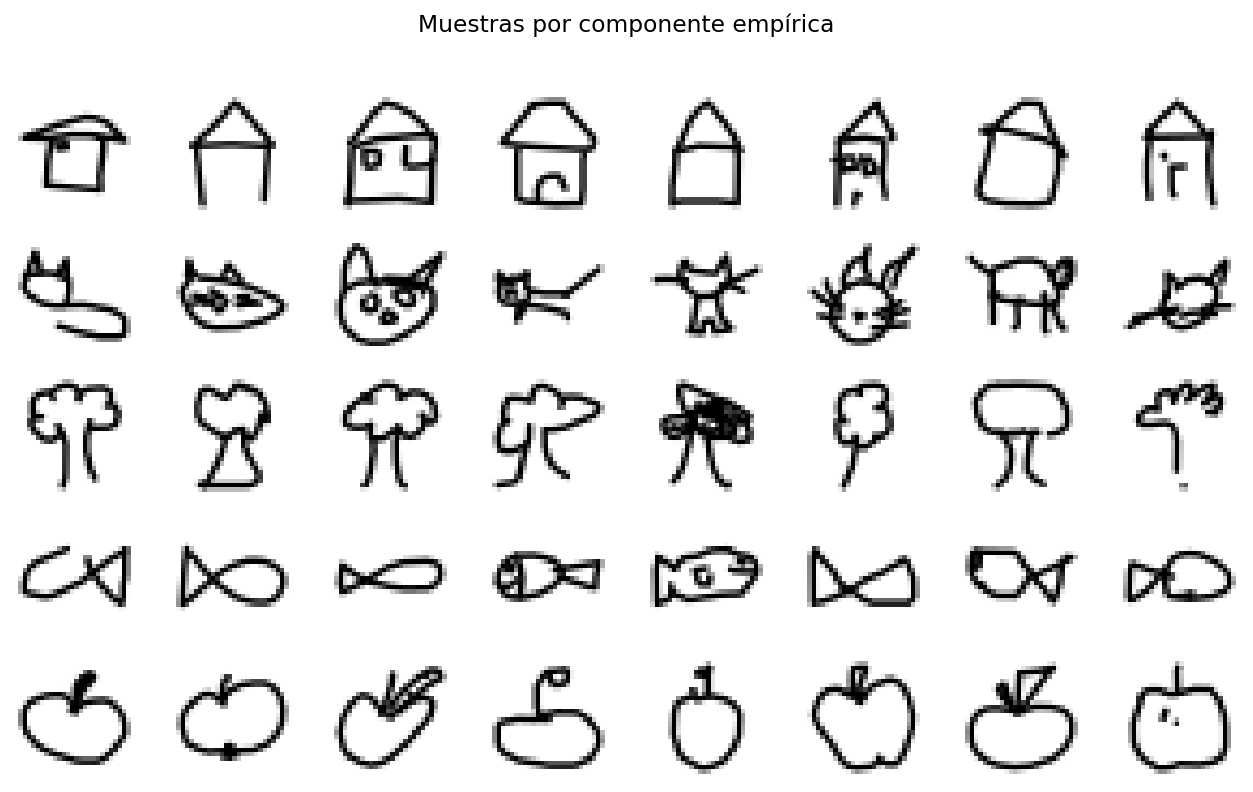

In [3]:
def show_class_grid(images, labels, names, samples_per_class=8, seed=SEED):
    local_rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(len(names), samples_per_class, figsize=(samples_per_class * 1.15, len(names) * 1.1))
    for k, name in enumerate(names):
        idx = np.flatnonzero(labels == k)
        chosen = local_rng.choice(idx, size=samples_per_class, replace=False)
        for j, image_idx in enumerate(chosen):
            ax = axes[k, j]
            ax.imshow(images[image_idx], vmin=0, vmax=255)
            ax.axis("off")
            if j == 0:
                ax.set_ylabel(str(name), rotation=0, ha="right", va="center", fontsize=10)
    fig.suptitle("Muestras por componente empírica", y=1.02)
    fig.tight_layout()
    return fig


show_class_grid(x_train, y_train, class_names)

## Prior empírico de clase

El prior $\widehat{\pi}_k$ determina con qué frecuencia aparece cada componente si muestreamos de la distribución marginal. En este subconjunto lo hacemos prácticamente balanceado para que el análisis sea controlado: cualquier diferencia visual observada proviene de la estructura de las clases, no de una dominancia artificial en el número de muestras.

 house: N_k= 8996, pi_hat=0.200
   cat: N_k= 8990, pi_hat=0.200
  tree: N_k= 8992, pi_hat=0.200
  fish: N_k= 9006, pi_hat=0.200
 apple: N_k= 9016, pi_hat=0.200


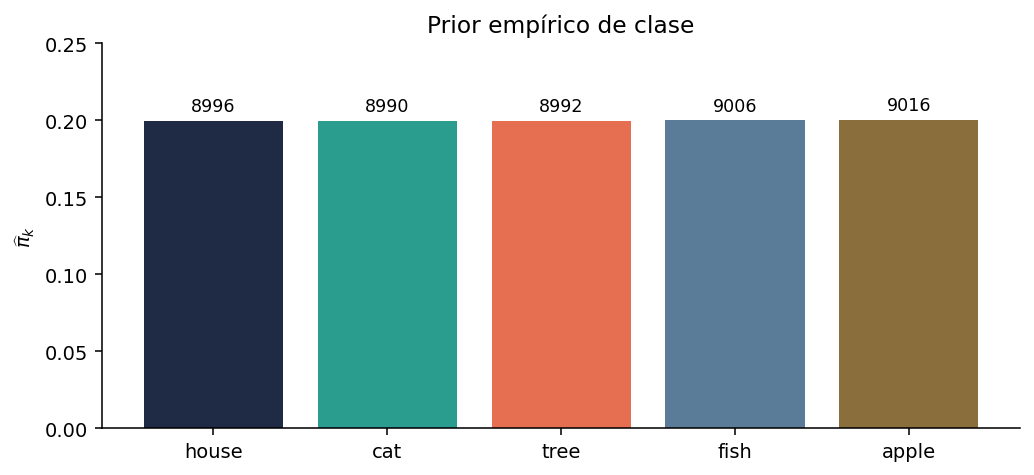

In [4]:
counts = np.bincount(y_train, minlength=K)
priors = counts / counts.sum()

fig, ax = plt.subplots(figsize=(7.5, 3.5))
bars = ax.bar(class_names, priors, color=["#1f2a44", "#2a9d8f", "#e76f51", "#5b7c99", "#8a6f3d"])
ax.set_ylabel(r"$\widehat{\pi}_k$")
ax.set_title("Prior empírico de clase")
ax.set_ylim(0, max(0.25, priors.max() * 1.18))
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.006, f"{count}", ha="center", fontsize=9)
fig.tight_layout()

for name, count, prior in zip(class_names, counts, priors):
    print(f"{name:>6s}: N_k={count:5d}, pi_hat={prior:.3f}")

## Momentos empíricos por clase

Una forma simple de resumir cada componente es calcular su promedio y su varianza pixel a pixel. El promedio no debe interpretarse como una muestra válida, sino como un estimador de estructura recurrente. La varianza muestra qué regiones cambian más dentro de una clase.

Para cada clase $k$ calculamos

$$
\widehat{\mu}_k
=
\frac{1}{N_k}
\sum_{i:y_i=k} x_i,
\qquad
\widehat{\sigma}^{2}_k
=
\frac{1}{N_k}
\sum_{i:y_i=k}
(x_i-\widehat{\mu}_k)^2.
$$

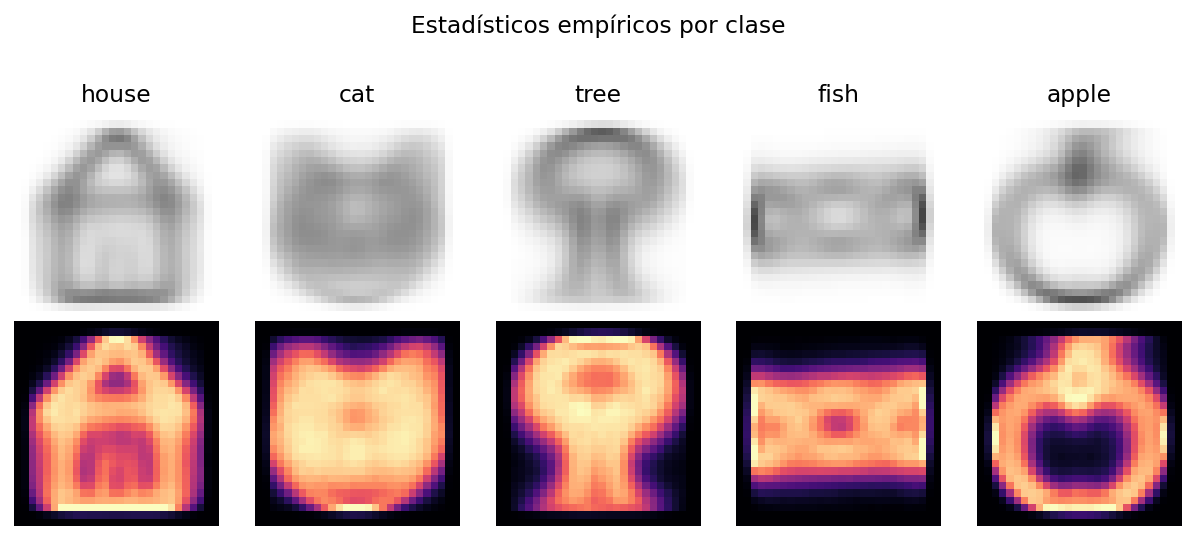

In [5]:
x_float = x_train.astype(np.float32) / 255.0
means = []
variances = []
for k in range(K):
    class_images = x_float[y_train == k]
    means.append(class_images.mean(axis=0))
    variances.append(class_images.var(axis=0))
means = np.stack(means)
variances = np.stack(variances)

fig, axes = plt.subplots(2, K, figsize=(K * 1.75, 3.7))
for k, name in enumerate(class_names):
    axes[0, k].imshow(means[k], vmin=0, vmax=1)
    axes[0, k].set_title(str(name))
    axes[0, k].axis("off")
    axes[1, k].imshow(variances[k], cmap="magma", vmin=0, vmax=np.percentile(variances, 99))
    axes[1, k].axis("off")
axes[0, 0].set_ylabel("Media", rotation=0, ha="right", va="center", fontsize=10)
axes[1, 0].set_ylabel("Varianza", rotation=0, ha="right", va="center", fontsize=10)
fig.suptitle("Estadísticos empíricos por clase", y=1.03)
fig.tight_layout()

## Proyección de baja dimensión

El espacio real tiene $784$ dimensiones. Para observar la mezcla en dos dimensiones usamos una proyección lineal obtenida por PCA sobre una muestra balanceada. Esta proyección no preserva toda la geometría, pero sí permite verificar que las clases no forman regiones perfectamente separadas: hay estructura semántica, variación intraclase y solapamiento entre componentes.

Si $X\in\mathbb{R}^{m\times d}$ es una matriz de imágenes vectorizadas y centradas, PCA toma los primeros vectores singulares derechos de $X$ y proyecta cada muestra sobre ellos. En términos computacionales, usamos una descomposición SVD reducida:

$$
X = U\Sigma V^\top,
\qquad
V_2 = [v_1,v_2],
\qquad
Z = X V_2.
$$

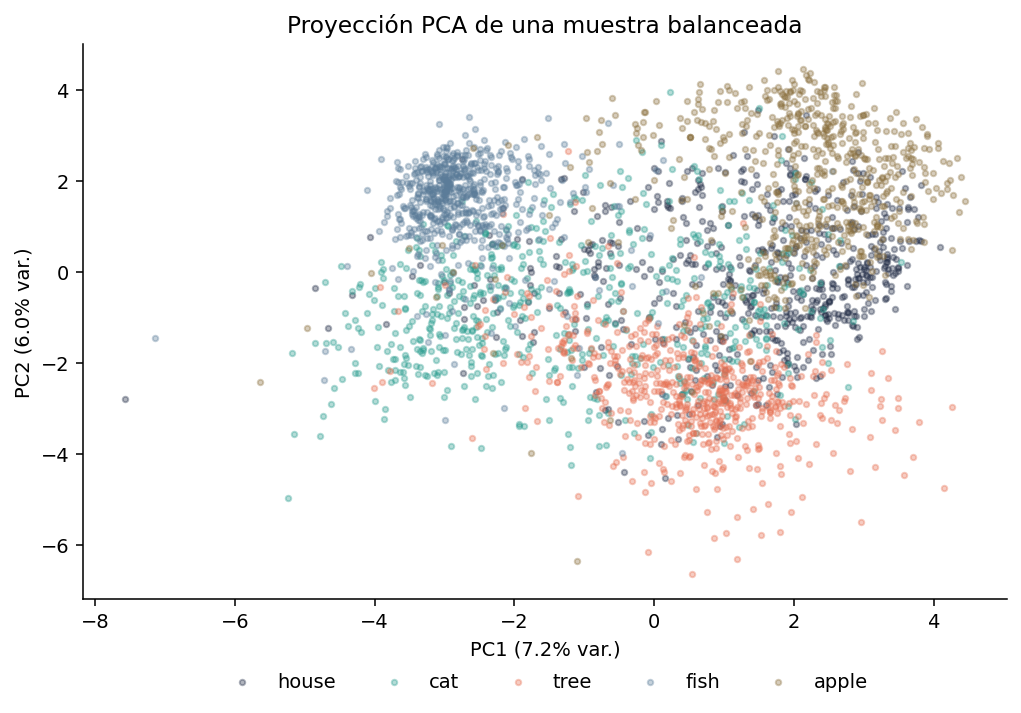

In [6]:
def balanced_subset(images, labels, n_per_class=600, seed=SEED):
    local_rng = np.random.default_rng(seed)
    selected = []
    for k in range(K):
        idx = np.flatnonzero(labels == k)
        selected.append(local_rng.choice(idx, size=n_per_class, replace=False))
    selected = np.concatenate(selected)
    local_rng.shuffle(selected)
    return images[selected], labels[selected]


x_pca, y_pca = balanced_subset(x_train, y_train, n_per_class=600)
X = x_pca.reshape(len(x_pca), -1).astype(np.float32) / 255.0
X = X - X.mean(axis=0, keepdims=True)

_, singular_values, vt = np.linalg.svd(X, full_matrices=False)
Z = X @ vt[:2].T
explained = singular_values[:2] ** 2 / np.sum(singular_values**2)

fig, ax = plt.subplots(figsize=(7.4, 5.2))
colors = ["#1f2a44", "#2a9d8f", "#e76f51", "#5b7c99", "#8a6f3d"]
for k, name in enumerate(class_names):
    mask = y_pca == k
    ax.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.35, label=str(name), color=colors[k])
ax.set_xlabel(f"PC1 ({100 * explained[0]:.1f}% var.)")
ax.set_ylabel(f"PC2 ({100 * explained[1]:.1f}% var.)")
ax.set_title("Proyección PCA de una muestra balanceada")
ax.legend(frameon=False, ncol=K, loc="upper center", bbox_to_anchor=(0.5, -0.10))
fig.tight_layout()

## Muestreo empírico marginal y condicional

Antes de entrenar un modelo, podemos contrastar dos formas de muestrear desde el dataset. El muestreo marginal ignora la etiqueta y produce imágenes de cualquier clase según $\widehat{\pi}_k$. El muestreo condicional fija una clase y toma muestras solo de la componente correspondiente.

Este experimento no es generación aprendida; es una demostración de las distribuciones que queremos aproximar. Precisamente por eso es útil antes de introducir un modelo condicional.

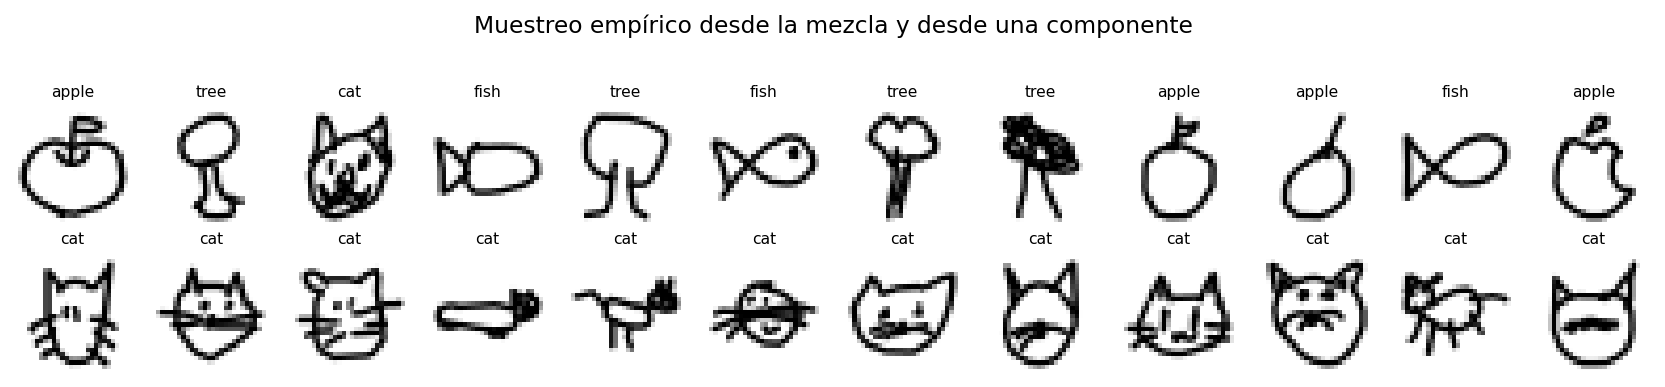

In [7]:
def sample_marginal(images, labels, n=12, seed=SEED + 1):
    local_rng = np.random.default_rng(seed)
    idx = local_rng.choice(len(images), size=n, replace=False)
    return images[idx], labels[idx]


def sample_conditional(images, labels, target_class, n=12, seed=SEED + 2):
    local_rng = np.random.default_rng(seed)
    idx = np.flatnonzero(labels == target_class)
    chosen = local_rng.choice(idx, size=n, replace=False)
    return images[chosen], labels[chosen]


marginal_images, marginal_labels = sample_marginal(x_train, y_train, n=12)
target_class = int(np.where(class_names == "cat")[0][0])
conditional_images, conditional_labels = sample_conditional(x_train, y_train, target_class, n=12)

fig, axes = plt.subplots(2, 12, figsize=(12, 2.7))
for j in range(12):
    axes[0, j].imshow(marginal_images[j], vmin=0, vmax=255)
    axes[0, j].set_title(str(class_names[marginal_labels[j]]), fontsize=8)
    axes[0, j].axis("off")
    axes[1, j].imshow(conditional_images[j], vmin=0, vmax=255)
    axes[1, j].set_title(str(class_names[conditional_labels[j]]), fontsize=8)
    axes[1, j].axis("off")
axes[0, 0].set_ylabel("Marginal", rotation=0, ha="right", va="center")
axes[1, 0].set_ylabel("Condicional", rotation=0, ha="right", va="center")
fig.suptitle("Muestreo empírico desde la mezcla y desde una componente", y=1.04)
fig.tight_layout()

## Difusión directa sobre varias componentes

La formulación forward del DDPM no cambia por tener varias clases: cada imagen se perturba en el mismo espacio $\mathbb{R}^{784}$. Lo que cambia es la interpretación del objetivo. A tiempos bajos todavía puede reconocerse la componente semántica; a tiempos altos, las muestras se vuelven visualmente cercanas al ruido gaussiano y la etiqueta deja de ser evidente para un observador humano.

Esta observación prepara el problema del notebook 07: si queremos que la cadena inversa produzca una clase específica, la red debe recibir información de la condición durante el denoising.

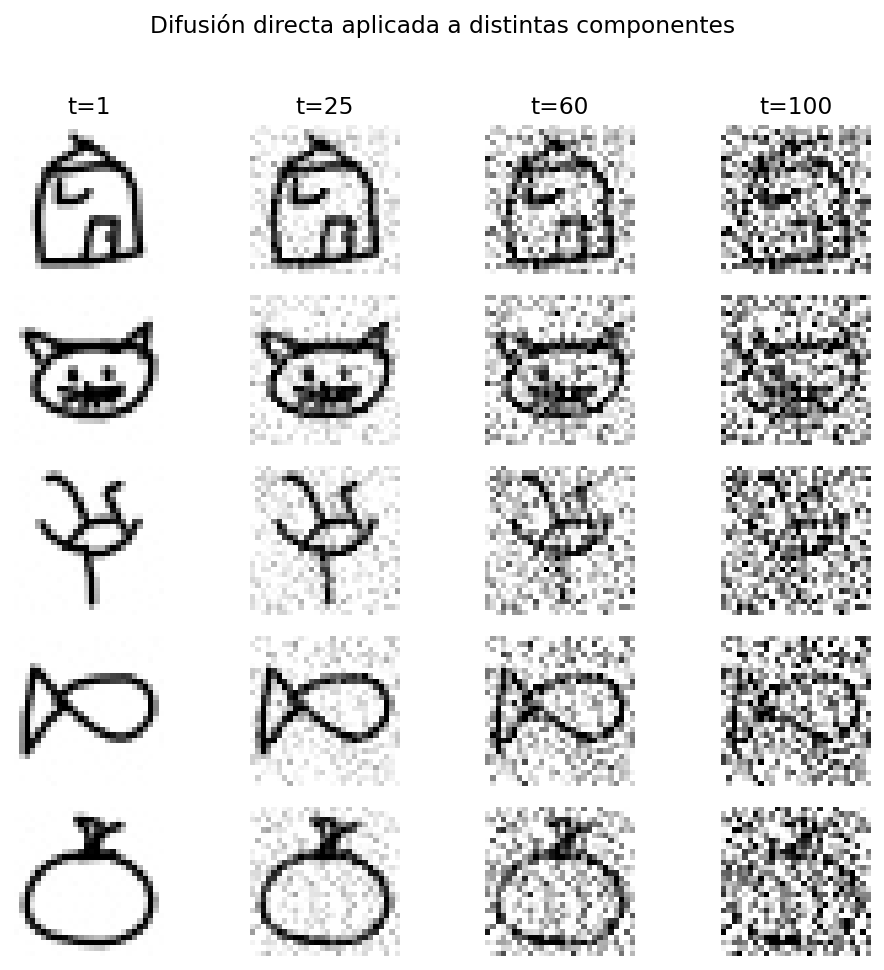

In [8]:
T = 100
betas = np.linspace(1e-4, 0.02, T, dtype=np.float32)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)


def forward_diffuse(x0, t_index, noise):
    x0 = x0.astype(np.float32) / 127.5 - 1.0
    return np.sqrt(alpha_bars[t_index]) * x0 + np.sqrt(1.0 - alpha_bars[t_index]) * noise


time_indices = [0, 24, 59, 99]
fig, axes = plt.subplots(K, len(time_indices), figsize=(len(time_indices) * 1.8, K * 1.35))
local_rng = np.random.default_rng(SEED + 3)
for k, name in enumerate(class_names):
    idx = local_rng.choice(np.flatnonzero(y_train == k))
    x0 = x_train[idx]
    noise = local_rng.normal(size=x0.shape).astype(np.float32)
    for j, t_index in enumerate(time_indices):
        xt = forward_diffuse(x0, t_index, noise)
        image = np.clip((xt + 1.0) / 2.0, 0.0, 1.0)
        ax = axes[k, j]
        ax.imshow(image, vmin=0, vmax=1)
        ax.axis("off")
        if k == 0:
            ax.set_title(f"t={t_index + 1}")
        if j == 0:
            ax.set_ylabel(str(name), rotation=0, ha="right", va="center", fontsize=10)
fig.suptitle("Difusión directa aplicada a distintas componentes", y=1.02)
fig.tight_layout()

## Consecuencia para el objetivo de entrenamiento

Si ignoramos las etiquetas, el modelo de ruido aprende una función única $\epsilon_\theta(x_t,t)$ para toda la mezcla. Esa función puede ser suficiente para generar muestras no condicionales, pero no contiene una interfaz explícita para seleccionar clase. En cambio, al usar $\epsilon_\theta(x_t,t,y)$, la etiqueta participa en cada paso de denoising y puede desplazar la cadena inversa hacia la componente deseada.

La diferencia computacional mínima será introducir una representación de $y$ dentro de la red. La diferencia estadística es más importante: el modelo deja de aproximar solamente una marginal y pasa a aproximar una familia de distribuciones condicionales.

## Síntesis

En este notebook pasamos de una distribución visual única a una mezcla de distribuciones. La formulación conjunta $p_{\mathrm{data}}(x,y)$ permite distinguir entre la marginal $p_{\mathrm{data}}(x)$ y las condicionales $p_{\mathrm{data}}(x\mid y=k)$. Esta distinción no es cosmética: determina si el modelo generativo puede producir cualquier muestra plausible de la mezcla o si puede ser dirigido hacia una clase específica.

El análisis empírico mostró tres hechos. Primero, las clases comparten el mismo espacio vectorial, por lo que el proceso de difusión directa puede aplicarse sin modificar su definición. Segundo, cada clase induce regularidades visuales propias que se observan en muestras, promedios y proyecciones. Tercero, la mezcla marginal pierde el mecanismo de selección semántica, lo cual motiva explícitamente los modelos de difusión condicionales.

## Preguntas de discusión

1. Si el dataset está balanceado, ¿por qué la marginal $\widehat{p}_{\mathrm{data}}(x)$ no se reduce a una distribución visual simple?
2. ¿Qué información se pierde cuando se entrena un modelo no condicional sobre un dataset etiquetado?
3. ¿Por qué la etiqueta $y$ no cambia el espacio de datos, pero sí cambia la familia de distribuciones que el modelo puede representar?
4. ¿Qué limitaciones tiene interpretar la separación de clases usando solo una proyección PCA de dos dimensiones?
5. En términos del objetivo de predicción de ruido, ¿qué diferencia introduce pasar de $\epsilon_\theta(x_t,t)$ a $\epsilon_\theta(x_t,t,y)$?

## Continuidad

El siguiente notebook introduce modelos de difusión condicionales. Partiremos del objetivo de predicción de ruido ya conocido y reemplazaremos

$$
\epsilon_\theta(x_t,t)
\quad
\text{por}
\quad
\epsilon_\theta(x_t,t,y).
$$

La pregunta ya no será solamente si el modelo puede generar una imagen plausible, sino si puede generar una imagen plausible de la clase solicitada.